<a href="https://colab.research.google.com/github/anaberereta-hue/Trabajos-Colab/blob/main/Aplicaci%C3%B3n_ACP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Componentes Principales

##Preprocesamiento mínimo del dataset Real-world vehicle emissions - archivo 2021_Cars_Raw.csv


##1. Visualización del archivo

In [27]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io

# URL para descarga directa desde GitHub
url_zip = 'https://github.com/anaberereta-hue/Reto-2-Base-de-datos/raw/main/2021_Cars_Raw.csv.zip'

try:
    # Descarga del archivo comprimido
    respuesta = requests.get(url_zip)

    # Procesamiento del contenido zip en memoria
    with zipfile.ZipFile(io.BytesIO(respuesta.content)) as contenido_zip:
        # Localizacion del archivo csv en el interior del zip
        archivo_interno = [nombre for nombre in contenido_zip.namelist() if nombre.endswith('.csv')][0]

        # Carga de datos a estructura DataFrame
        with contenido_zip.open(archivo_interno) as archivo_csv:
            df_autos = pd.read_csv(archivo_csv)

    print("Carga finalizada con éxito.")

    # Visualizacion de las primeras 11 filas del dataset
    display(df_autos.head(11))

except Exception as e:
    print("Error durante la ejecucion:", e)

Carga finalizada con éxito.


,OBFCM data source,ID,OBFCM ReportingPeriod,Registration Year,Total fuel consumed (lifetime) (l),Total distance travelled (lifetime) (km),Total distance travelled in charge depleting operation with engine off (lifetime) (km),Total distance travelled in charge depleting operation with engine running (lifetime) (km),Total distance travelled in driver-selectable charge increasing operation (lifetime) (km),Total fuel consumed in charge depleting operation (lifetime) (l),Total fuel consumed in driver-selectable charge increasing operation (lifetime) (l),Total grid energy into the battery (lifetime) (kWh),Used in calculation
0,OEM,55201566,2021,2021,645.57,8077.5,707.6,2561.5,0.0,248.34,0.00,102.4,1
1,OEM,46868086,2021,2021,1363.64,25085.7,10457.4,7449.2,0.0,720.74,0.00,3098.3,1
2,OEM,55201567,2021,2021,121.03,3585.7,2371.1,1064.8,0.0,108.56,0.00,850.7,1
3,OEM,55201568,2021,2021,311.34,6770.1,3605.6,1466.6,0.0,160.05,0.00,1216.7,1
4,OEM,55201574,2021,2021,690.69,10727.7,3226.1,1079.8,0.0,125.23,0.00,1155.0,1
5,OEM,56905353,2021,2021,703.07,10670.4,3183.1,2400.0,0.0,250.00,0.00,934.9,1
6,OEM,55201575,2021,2021,1812.90,28690.1,10522.5,12880.4,0.0,1315.02,0.00,3472.6,1
7,OEM,46757539,2021,2021,1487.99,26092.6,10183.0,1408.2,29.1,148.40,4.89,3288.4,1
8,OEM,46794937,2021,2021,2036.70,20643.9,4110.6,6424.2,0.1,757.75,0.00,1623.0,1
9,OEM,46787477,2021,2021,826.45,9492.2,1569.1,284.3,8.1,32.40,1.16,346.0,1


##2. Seleccion de variables cuantitativas

In [47]:
import numpy as np

# Definimos la variable 'df_cuantitativas' para almacenar una copia del dataset original
# pero filtrando exclusivamente las columnas que contienen números.
# El Análisis de Componentes Principales (ACP) es una técnica matemática que opera
# con varianzas y covarianzas, por lo que exige datos estrictamente numéricos.
df_cuantitativas = df_autos.select_dtypes(include=[np.number])

# Extraemos los nombres de las columnas resultantes y las guardamos en 'columnas_seleccionadas'
# Necesitamos saber exactamente qué variables entraron al filtro para nuestro análisis.
columnas_seleccionadas = df_cuantitativas.columns.tolist()

print("Las variables cuantitativas seleccionadas para el ACP son:")
# Repetimos sobre la lista para imprimir cada nombre de columna de forma ordenada
for columna in columnas_seleccionadas:
    print(f"- {columna}")

print("\nVista previa de la nueva tabla (solo números):")
# Visualizamos las primeras 11 filas para confirmar el resultado
display(df_cuantitativas.head(11))

Las variables cuantitativas seleccionadas para el ACP son:
- ID
- OBFCM ReportingPeriod
- Registration Year
- Total fuel consumed (lifetime) (l)
- Total distance travelled (lifetime) (km)
- Total distance travelled in charge depleting operation with engine off (lifetime) (km)
- Total distance travelled in charge depleting operation with engine running (lifetime) (km)
- Total distance travelled in driver-selectable charge increasing operation (lifetime)  (km)
- Total fuel consumed in charge depleting operation (lifetime) (l)
- Total fuel consumed in driver-selectable charge increasing operation (lifetime) (l)
- Total grid energy into the battery (lifetime) (kWh)
- Used in calculation

Vista previa de la nueva tabla (solo números):


,ID,OBFCM ReportingPeriod,Registration Year,Total fuel consumed (lifetime) (l),Total distance travelled (lifetime) (km),Total distance travelled in charge depleting operation with engine off (lifetime) (km),Total distance travelled in charge depleting operation with engine running (lifetime) (km),Total distance travelled in driver-selectable charge increasing operation (lifetime) (km),Total fuel consumed in charge depleting operation (lifetime) (l),Total fuel consumed in driver-selectable charge increasing operation (lifetime) (l),Total grid energy into the battery (lifetime) (kWh),Used in calculation
0,55201566,2021,2021,645.57,8077.5,707.6,2561.5,0.0,248.34,0.00,102.4,1
1,46868086,2021,2021,1363.64,25085.7,10457.4,7449.2,0.0,720.74,0.00,3098.3,1
2,55201567,2021,2021,121.03,3585.7,2371.1,1064.8,0.0,108.56,0.00,850.7,1
3,55201568,2021,2021,311.34,6770.1,3605.6,1466.6,0.0,160.05,0.00,1216.7,1
4,55201574,2021,2021,690.69,10727.7,3226.1,1079.8,0.0,125.23,0.00,1155.0,1
5,56905353,2021,2021,703.07,10670.4,3183.1,2400.0,0.0,250.00,0.00,934.9,1
6,55201575,2021,2021,1812.90,28690.1,10522.5,12880.4,0.0,1315.02,0.00,3472.6,1
7,46757539,2021,2021,1487.99,26092.6,10183.0,1408.2,29.1,148.40,4.89,3288.4,1
8,46794937,2021,2021,2036.70,20643.9,4110.6,6424.2,0.1,757.75,0.00,1623.0,1
9,46787477,2021,2021,826.45,9492.2,1569.1,284.3,8.1,32.40,1.16,346.0,1


##3. Comprobar la cantidad de datos faltantes

In [48]:
# Exploración de datos faltantes (NaN) en nuestras variables numéricas
# La función isnull() detecta las celdas vacías y sum() las suma por cada columna.
faltantes = df_cuantitativas.isnull().sum()

print("Cantidad de celdas vacías por columna:")
display(faltantes)

Cantidad de celdas vacías por columna:


,0
ID,0
OBFCM ReportingPeriod,0
Registration Year,0
Total fuel consumed (lifetime) (l),0
Total distance travelled (lifetime) (km),0
Total distance travelled in charge depleting operation with engine off (lifetime) (km),471568
Total distance travelled in charge depleting operation with engine running (lifetime) (km),471723
Total distance travelled in driver-selectable charge increasing operation (lifetime) (km),468250
Total fuel consumed in charge depleting operation (lifetime) (l),474685
Total fuel consumed in driver-selectable charge increasing operation (lifetime) (l),478374


##4. Limpieza de datos faltantes

In [49]:
# Calculamos la mediana de cada columna numérica
# La mediana es el valor central de los datos ordenados.
medianas = df_cuantitativas.median()

# Llenamos los valores vacíos (NaN) con la mediana calculada
# El ACP requiere una matriz de datos completa para calcular la covarianza.
df_limpio = df_cuantitativas.fillna(medianas)

# Verificación de la limpieza
faltantes_totales = df_limpio.isnull().sum().sum()
print(f"Total de celdas vacías tras imputar con la mediana: {faltantes_totales}")

print("\nVista previa de la tabla con datos imputados:")
# Mantenemos la configuración de visualizar 11 filas
display(df_limpio.head(11))

Total de celdas vacías tras imputar con la mediana: 0

Vista previa de la tabla con datos imputados:


,ID,OBFCM ReportingPeriod,Registration Year,Total fuel consumed (lifetime) (l),Total distance travelled (lifetime) (km),Total distance travelled in charge depleting operation with engine off (lifetime) (km),Total distance travelled in charge depleting operation with engine running (lifetime) (km),Total distance travelled in driver-selectable charge increasing operation (lifetime) (km),Total fuel consumed in charge depleting operation (lifetime) (l),Total fuel consumed in driver-selectable charge increasing operation (lifetime) (l),Total grid energy into the battery (lifetime) (kWh),Used in calculation
0,55201566,2021,2021,645.57,8077.5,707.6,2561.5,0.0,248.34,0.00,102.4,1
1,46868086,2021,2021,1363.64,25085.7,10457.4,7449.2,0.0,720.74,0.00,3098.3,1
2,55201567,2021,2021,121.03,3585.7,2371.1,1064.8,0.0,108.56,0.00,850.7,1
3,55201568,2021,2021,311.34,6770.1,3605.6,1466.6,0.0,160.05,0.00,1216.7,1
4,55201574,2021,2021,690.69,10727.7,3226.1,1079.8,0.0,125.23,0.00,1155.0,1
5,56905353,2021,2021,703.07,10670.4,3183.1,2400.0,0.0,250.00,0.00,934.9,1
6,55201575,2021,2021,1812.90,28690.1,10522.5,12880.4,0.0,1315.02,0.00,3472.6,1
7,46757539,2021,2021,1487.99,26092.6,10183.0,1408.2,29.1,148.40,4.89,3288.4,1
8,46794937,2021,2021,2036.70,20643.9,4110.6,6424.2,0.1,757.75,0.00,1623.0,1
9,46787477,2021,2021,826.45,9492.2,1569.1,284.3,8.1,32.40,1.16,346.0,1


## 5. Estandarización

In [50]:
from sklearn.preprocessing import StandardScaler

# Definimos el objeto escalador.
# El ACP busca las direcciones de máxima varianza. Si una variable tiene números
# muy grandes y otra muy pequeños, la de números
# grandes dominará el cálculo de autovalores de forma errónea.
escalador = StandardScaler()

# Aplicamos el escalado a los datos que ya limpiamos con la mediana.
# El método fit_transform hace dos cosas:
# 1. Centra los datos (resta la media para que el promedio sea 0).
# 2. Escala los datos (divide por la desviación estándar para que la varianza sea 1).
matriz_estandarizada = escalador.fit_transform(df_limpio)

# Convertimos el resultado (que es un array de numpy) de vuelta a un DataFrame de Pandas
# para mantener los nombres de las columnas y poder visualizarlo.
df_estandarizado = pd.DataFrame(matriz_estandarizada, columns=df_limpio.columns)

print("Estandarización finalizada con éxito.")
print("\nVista previa de la tabla ESTANDARIZADA (Lista para el ACP):")
# Visualizamos las primeras 11 filas como lo tienes configurado
display(df_estandarizado.head(11))

Estandarización finalizada con éxito.

Vista previa de la tabla ESTANDARIZADA (Lista para el ACP):


,ID,OBFCM ReportingPeriod,Registration Year,Total fuel consumed (lifetime) (l),Total distance travelled (lifetime) (km),Total distance travelled in charge depleting operation with engine off (lifetime) (km),Total distance travelled in charge depleting operation with engine running (lifetime) (km),Total distance travelled in driver-selectable charge increasing operation (lifetime) (km),Total fuel consumed in charge depleting operation (lifetime) (l),Total fuel consumed in driver-selectable charge increasing operation (lifetime) (l),Total grid energy into the battery (lifetime) (kWh),Used in calculation
0,0.545934,0.0,0.0,0.216107,0.042454,-0.010431,-0.009264,-0.078311,-0.009435,-0.057141,-0.000978,0.696116
1,-0.038174,0.0,0.0,1.282369,0.861786,-0.006043,-0.007063,-0.078311,-0.007309,-0.057141,0.012376,0.696116
2,0.545934,0.0,0.0,-0.562781,-0.173928,-0.009682,-0.009938,-0.078311,-0.010065,-0.057141,0.002357,0.696116
3,0.545934,0.0,0.0,-0.280190,-0.020527,-0.009127,-0.009757,-0.078311,-0.009833,-0.057141,0.003989,0.696116
4,0.545935,0.0,0.0,0.283106,0.170122,-0.009297,-0.009932,-0.078311,-0.009990,-0.057141,0.003714,0.696116
5,0.665356,0.0,0.0,0.301489,0.167362,-0.009317,-0.009337,-0.078311,-0.009428,-0.057141,0.002733,0.696116
6,0.545935,0.0,0.0,1.949474,1.035420,-0.006014,-0.004618,-0.078311,-0.004633,-0.057141,0.014044,0.696116
7,-0.045923,0.0,0.0,1.467016,0.910291,-0.006167,-0.009784,-0.078310,-0.009885,-0.057139,0.013223,0.696116
8,-0.043302,0.0,0.0,2.281794,0.647812,-0.008899,-0.007525,-0.078311,-0.007142,-0.057141,0.005800,0.696116
9,-0.043825,0.0,0.0,0.484696,0.110604,-0.010043,-0.010290,-0.078311,-0.010408,-0.057141,0.000108,0.696116


##6. Ejecución de ACP (2 y 3 componentes)

In [39]:
from sklearn.decomposition import PCA

#1. EJECUCIÓN DEL ACP PARA 2 COMPONENTES
pca_2d = PCA(n_components=2)
componentes_2d = pca_2d.fit_transform(df_estandarizado)
df_pca_2d = pd.DataFrame(data=componentes_2d, columns=['PC1', 'PC2'])

#2. EJECUCIÓN DEL ACP PARA 3 COMPONENTES
pca_3d = PCA(n_components=3)
componentes_3d = pca_3d.fit_transform(df_estandarizado)
df_pca_3d = pd.DataFrame(data=componentes_3d, columns=['PC1', 'PC2', 'PC3'])

#3. REVISIÓN DE RESULTADOS
var_2d = pca_2d.explained_variance_ratio_.sum() * 100
var_3d = pca_3d.explained_variance_ratio_.sum() * 100

print(f"Varianza total explicada (2 CP): {var_2d:.2f}%")
print(f"Varianza total explicada (3 CP): {var_3d:.2f}%")

#4. VISTAS PREVIAS
print("\n")
print("VISTA PREVIA: 2 COMPONENTES")
display(df_pca_2d.head(11))

print("\n")
print("VISTA PREVIA: 3 COMPONENTES")
display(df_pca_3d.head(11))

Varianza total explicada (2 CP): 48.24%
Varianza total explicada (3 CP): 64.90%


VISTA PREVIA: 2 COMPONENTES


,PC1,PC2
0,-0.047785,0.541261
1,-0.050343,1.402558
2,-0.043937,0.058818
3,-0.045069,0.264115
4,-0.048446,0.626750
5,-0.047750,0.637205
6,-0.050322,1.821961
7,-0.054425,1.515340
8,-0.056353,1.822921
9,-0.050752,0.694152




VISTA PREVIA: 3 COMPONENTES


,PC1,PC2,PC3
0,-0.047785,0.541261,0.225685
1,-0.050343,1.402558,0.895308
2,-0.043937,0.058818,-0.161156
3,-0.045069,0.264115,0.004607
4,-0.048446,0.626750,0.296044
5,-0.047750,0.637205,0.310047
6,-0.050322,1.821961,1.259623
7,-0.054425,1.515340,0.985932
8,-0.056353,1.822921,1.224461
9,-0.050752,0.694152,0.319367


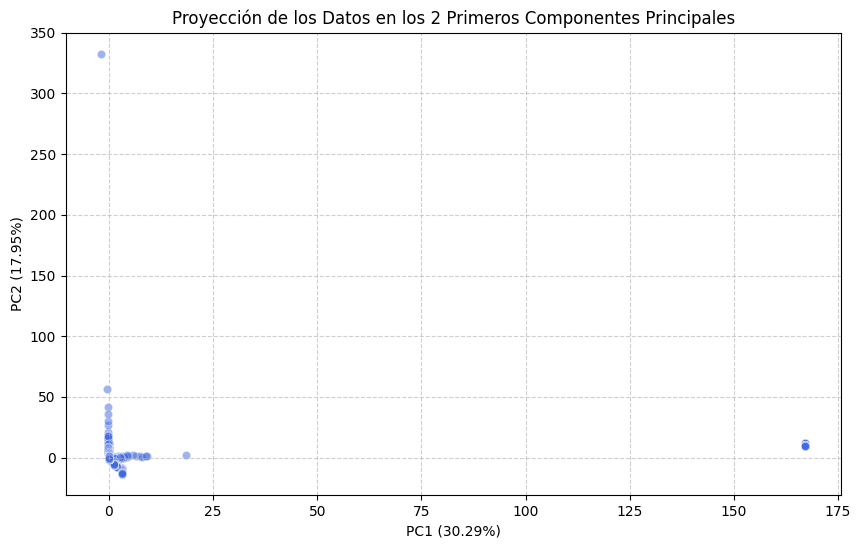

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca_2d, alpha=0.5, color='royalblue')
plt.title('Proyección de los Datos en los 2 Primeros Componentes Principales')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

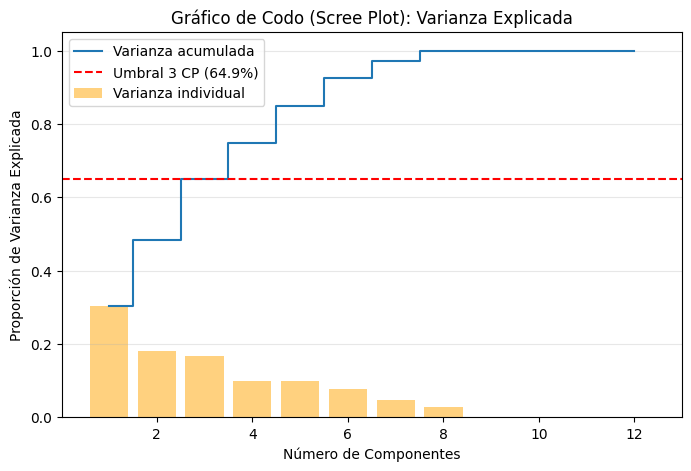

In [41]:
import numpy as np

# Calculamos la varianza de todos los componentes posibles
pca_total = PCA().fit(df_estandarizado)
varianza_acumulada = np.cumsum(pca_total.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid', label='Varianza acumulada')
plt.bar(range(1, len(pca_total.explained_variance_ratio_) + 1), pca_total.explained_variance_ratio_,
        alpha=0.5, align='center', label='Varianza individual', color='orange')

plt.title('Gráfico de Codo (Scree Plot): Varianza Explicada')
plt.xlabel('Número de Componentes')
plt.ylabel('Proporción de Varianza Explicada')
plt.axhline(y=0.649, color='r', linestyle='--', label='Umbral 3 CP (64.9%)') # Tu dato real
plt.legend(loc='best')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [42]:
# Creamos la tabla de cargas para los 3 componentes
cargas = pd.DataFrame(pca_3d.components_.T,
                      columns=['PC1', 'PC2', 'PC3'],
                      index=df_limpio.columns)

print("--- TABLA DE CARGAS (LOADINGS) ---")
print("Valores altos (cercanos a 1 o -1) indican una fuerte influencia de la variable en el componente.")
display(cargas.style.background_gradient(cmap='coolwarm')) # El color ayuda a identificar pesos altos

--- TABLA DE CARGAS (LOADINGS) ---
Valores altos (cercanos a 1 o -1) indican una fuerte influencia de la variable en el componente.


,PC1,PC2,PC3
ID,0.001062,0.018240,0.063809
OBFCM ReportingPeriod,0.000000,0.000000,0.000000
Registration Year,0.000000,0.000000,0.000000
Total fuel consumed (lifetime) (l),-0.004704,0.507258,0.402252
Total distance travelled (lifetime) (km),-0.002314,0.403496,0.339983
Total distance travelled in charge depleting operation with engine off (lifetime) (km),0.570780,0.057254,-0.064724
Total distance travelled in charge depleting operation with engine running (lifetime) (km),0.570762,0.057238,-0.064731
Total distance travelled in driver-selectable charge increasing operation (lifetime) (km),0.096836,-0.400227,0.571084
Total fuel consumed in charge depleting operation (lifetime) (l),0.570861,0.057269,-0.064758
Total fuel consumed in driver-selectable charge increasing operation (lifetime) (l),0.112169,-0.391257,0.568993
